<a href="https://colab.research.google.com/github/Paulmora23/ENTREGABLE_BIT_PAULAMOLINA/blob/main/Entregable_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1-CARGA Y EXPLORACIÓN INICIAL

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,5)

In [5]:
df= pd.read_csv('/netflix_titles.csv')

In [7]:
print(f"filas: {df.shape[0]}")
print(f"columnas: {df.shape[1]}")

filas: 8807
columnas: 12


#2-DATOS DUPLICADOS

In [8]:
duplicados = df.duplicated().sum()
print(f"Registros duplicados: {duplicados}")

Registros duplicados: 0


DATOS NULOS

In [9]:
print("\nConteo y porcentaje de valores nulos:")
nulos = df.isnull().sum()
porcentaje_nulos = (df.isnull().sum() / len(df)) * 100
print(pd.DataFrame({'Conteo': nulos, 'Porcentaje': porcentaje_nulos}))


Conteo y porcentaje de valores nulos:
              Conteo  Porcentaje
show_id            0    0.000000
type               0    0.000000
title              0    0.000000
director        2634   29.908028
cast             825    9.367549
country          831    9.435676
date_added        10    0.113546
release_year       0    0.000000
rating             4    0.045418
duration           3    0.034064
listed_in          0    0.000000
description        0    0.000000


#LIMPIEZA,FILTRADO  Y TRANSFORMACION DE DATOS

In [10]:
#Imputación de variables categoricas con fillna
df['director']= df['director'].fillna('Desconocido')
df['cast']=df['cast'].fillna('Desconocido')
df['country']= df['country'].fillna('Desconocido')

In [11]:
#Eliminacion de filas reciduales criticas
df= df.dropna(subset=['date_added','rating','duration']).copy()

In [12]:
#Tranformación de fechas
df['date_added']= pd.to_datetime(df['date_added'].str.strip(),errors='coerce')
df['year_added']= df['date_added'].dt.year.astype(int)
df['month_added']= df['date_added'].dt.month_name()

In [13]:
#Creacion de variables numericas para duración
df['duration_num']= df['duration'].str.extract('(\d+)').astype(float)
df['duration_type']= df['duration'].str.extract('([a-zA-Z]+)')

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_3111/2672992347.py:2: SyntaxWarning: invalid escape sequence '\d'
  df['duration_num']= df['duration'].str.extract('(\d+)').astype(float)


In [14]:
# Extracción del país principal (primer país listado)
df['primary_country'] = df['country'].apply(lambda x: x.split(',')[0].strip())

In [15]:
# Extracción del género principal
df['primary_genre'] = df['listed_in'].apply(lambda x: x.split(',')[0].strip())

display(df[['title', 'type', 'primary_country', 'year_added', 'duration_num', 'primary_genre']].head())

,title,type,primary_country,year_added,duration_num,primary_genre
0,Dick Johnson Is Dead,Movie,United States,2021,90.0,Documentaries
1,Blood & Water,TV Show,South Africa,2021,2.0,International TV Shows
2,Ganglands,TV Show,Desconocido,2021,1.0,Crime TV Shows
3,Jailbirds New Orleans,TV Show,Desconocido,2021,1.0,Docuseries
4,Kota Factory,TV Show,India,2021,2.0,International TV Shows


#3-4 Preguntas de Análisis con Gráficas e Interpretación

#Pregunta 1 ¿Cuál es la proporción entre películas y series de televisión en el catálogo?

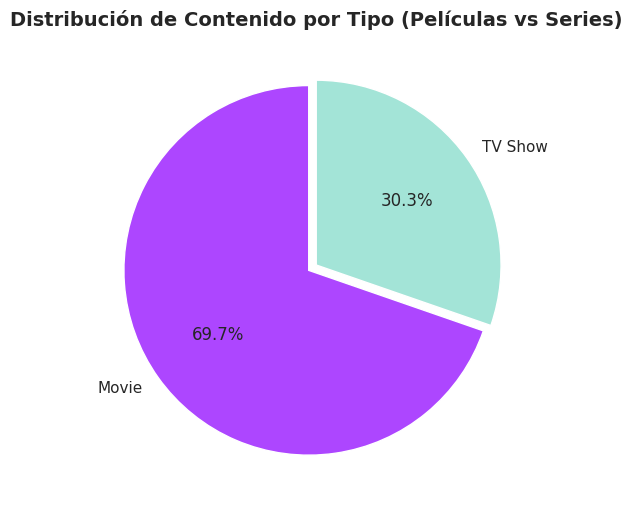

In [22]:
conteo_tipo = df['type'].value_counts()

plt.figure(figsize=(6, 6))
colors = ['#AD46FF', '#A3E4D7']
plt.pie(conteo_tipo, labels=conteo_tipo.index, autopct='%1.1f%%', startangle=90, colors=colors, explode=(0.05, 0))
plt.title('Distribución de Contenido por Tipo (Películas vs Series)', fontsize=14, fontweight='bold')
plt.show()

Las películas representan cerca del 70% del catálogo histórico de Netflix, superando con mayor relevancia a las series. La plataforma construyó su oferta inicial basándose en largometrajes.

#Pregunta 2: ¿Cómo ha evolucionado la adición anual de contenido a la plataforma?

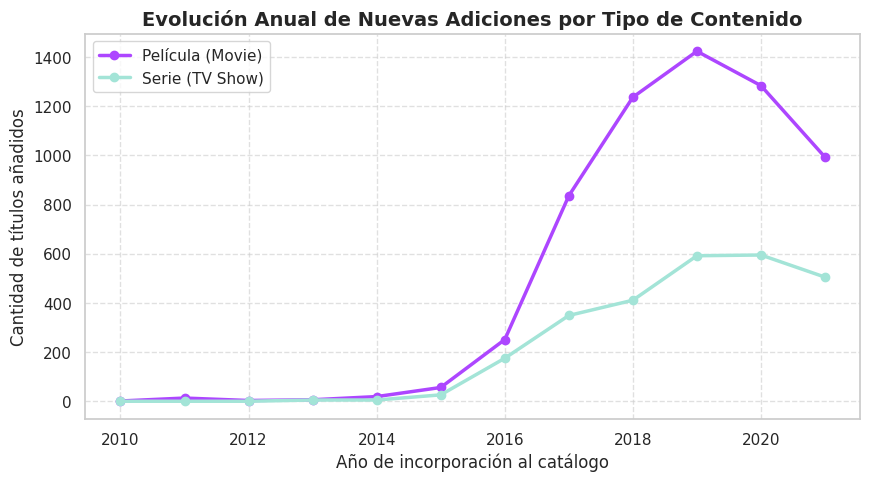

In [21]:
evolucion = df.groupby(['year_added', 'type'])['show_id'].count().unstack().fillna(0)
evolucion = evolucion[evolucion.index >= 2010]  # Filtrar años con suficiente volumen

evolucion.plot(kind='line', marker='o', linewidth=2.5, color=['#AD46FF', '#A3E4D7'])
plt.title('Evolución Anual de Nuevas Adiciones por Tipo de Contenido', fontsize=14, fontweight='bold')
plt.xlabel('Año de incorporación al catálogo', fontsize=12)
plt.ylabel('Cantidad de títulos añadidos', fontsize=12)
plt.legend(['Película (Movie)', 'Serie (TV Show)'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Se evidencia un crecimiento exponencial entre 2015 y 2019, alcanzando un pico de incorporaciones previo a 2020. En 2020-2021 se estabiliza la incorporación de películas, mientras que la brecha con las series se reduce como parte de una estrategia de fidelización continua.

#Pregunta 3: ¿Cuáles son los 10 países con mayor producción de títulos en Netflix?

/tmp/ipykernel_3111/1673958113.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_paises.values, y=top_paises.index, palette='Reds_r')


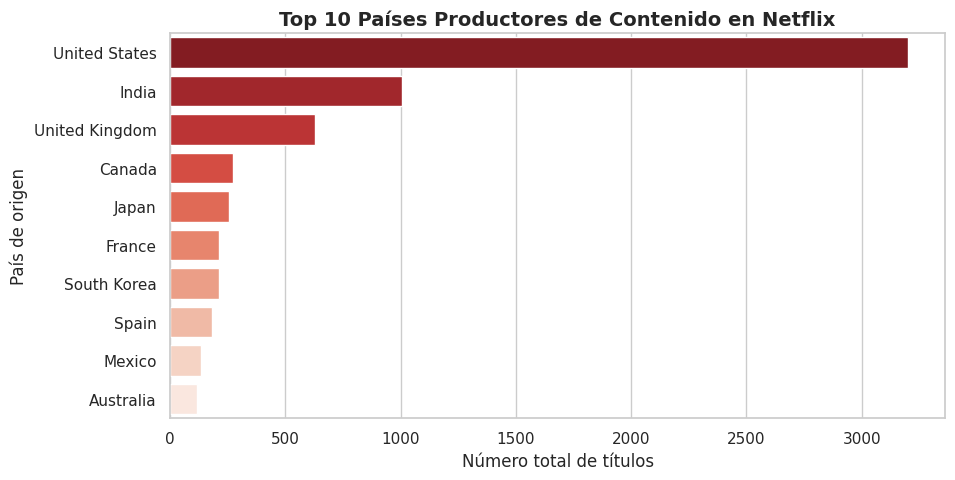

In [24]:
top_paises = df[df['primary_country'] != 'Desconocido']['primary_country'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_paises.values, y=top_paises.index, hue=top_paises.index, palette='Reds_r', legend=False)
plt.title('Top 10 Países Productores de Contenido en Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Número total de títulos', fontsize=12)
plt.ylabel('País de origen', fontsize=12)
plt.show()

Estados Unidos lidera con una diferencia notable, seguido por India y Reino Unido. Esto resalta el peso del mercado norteamericano y la expansión, contrastando con mercados europeos y asiáticos que tienen un volumen menor pero especializado.

#Pregunta 4: ¿Cuál es la clasificación por edad (rating) más frecuente en el catálogo?

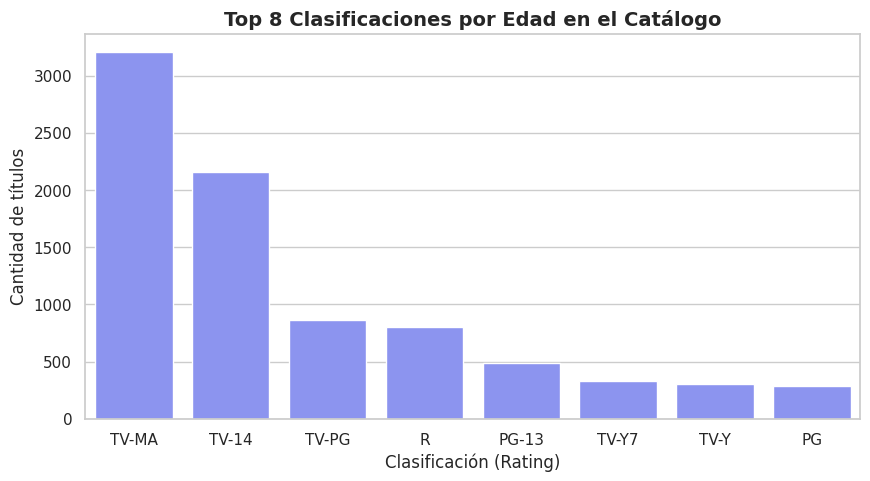

In [26]:
conteo_rating = df['rating'].value_counts().head(8)

plt.figure(figsize=(10, 5))
sns.barplot(x=conteo_rating.index, y=conteo_rating.values, color='#7C86FF')
plt.title('Top 8 Clasificaciones por Edad en el Catálogo', fontsize=14, fontweight='bold')
plt.xlabel('Clasificación (Rating)', fontsize=12)
plt.ylabel('Cantidad de títulos', fontsize=12)
plt.show()

Las categorías dominantes son TV-MA (para adultos) y TV-14 (mayores de 14 años). Esto demuestra que el catálogo central de Netflix está enfocado en audiencias adultas y adolescentes, mientras que el contenido infantil (TV-Y, G) ocupa un segmento menor.

#Pregunta 5: ¿Cómo se distribuye la duración de las películas (en minutos)?

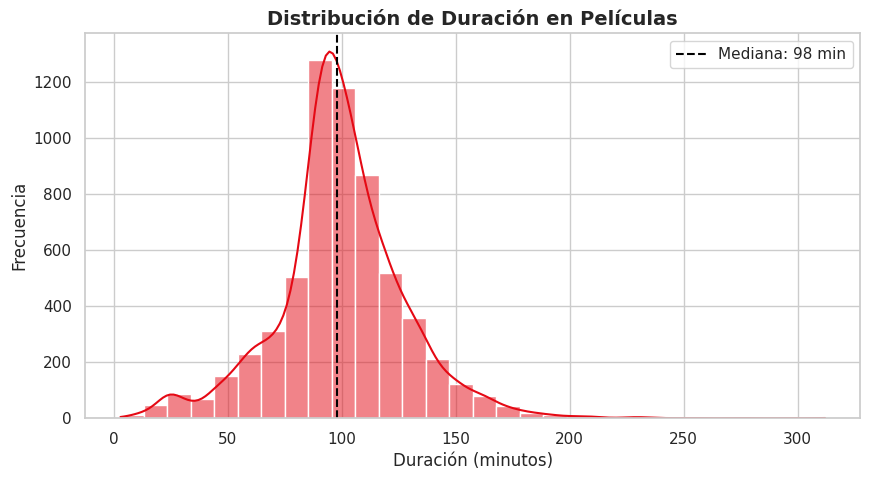

In [27]:
peliculas = df[df['type'] == 'Movie']

plt.figure(figsize=(10, 5))
sns.histplot(peliculas['duration_num'], kde=True, bins=30, color='#E50914')
plt.axvline(peliculas['duration_num'].median(), color='black', linestyle='--', label=f"Mediana: {peliculas['duration_num'].median():.0f} min")
plt.title('Distribución de Duración en Películas', fontsize=14, fontweight='bold')
plt.xlabel('Duración (minutos)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.legend()
plt.show()

La duración sigue una distribución normal casi perfecta, centrada alrededor de los 100 minutos. Hay una baja dispersión hacia metrajes de menos de 60 minutos o de más de 160 minutos, respondiendo al formato comercial clásico de largometrajes cinematográficos.

#5-CONCLUSIONES

⭐Estrategia centrada en audiencias maduras: El catálogo concentra más del 60% de sus producciones en clasificaciones TV-MA y TV-14. Esto refleja una apuesta intencional por capturar suscriptores con capacidad de pago directo (adultos y familias con adolescentes), relegando el contenido estrictamente infantil a un rol complementario.

⭐Consolidación de mercados globales clave: Aunque Estados Unidos sigue siendo el mayor proveedor de contenido, India se ha afianzado como el segundo polo de producción en volumen dentro de la plataforma. Esto evidencia una estrategia de penetración profunda en mercados emergentes masivos mediante producciones locales que complementan a Hollywood.

⭐Estandarización del formato cinematográfico: A pesar de ser una plataforma de distribución digital sin restricciones de salas de cine, la duración de las películas mantiene rígidamente la norma tradicional de la industria (mediana de 100 minutos). Netflix adapta su ritmo de consumo a los hábitos consolidados del espectador estándar, evitando experimentar mayoritariamente con formatos de ultralarga o extracorta duración.

